# Superstore Sales EDA
## Uncovering Profit Leaks Through Data Analysis

**Dataset:** Sample Superstore (9,994 transactions)  
**Goal:** Identify why certain regions, categories, and products are losing money despite high sales.  
**Tools:** Python, Pandas, Matplotlib, Seaborn

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Style settings
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")
plt.rcParams['figure.dpi'] = 150
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.titleweight'] = 'bold'

In [3]:
df = pd.read_csv('SampleSuperstore.csv')

In [4]:
df.head()

,Ship Mode,Segment,Country,City,State,Postal Code,Region,Category,Sub-Category,Sales,Quantity,Discount,Profit
0,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Bookcases,261.9600,2,0.00,41.9136
1,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Chairs,731.9400,3,0.00,219.5820
2,Second Class,Corporate,United States,Los Angeles,California,90036,West,Office Supplies,Labels,14.6200,2,0.00,6.8714
3,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Furniture,Tables,957.5775,5,0.45,-383.0310
4,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Office Supplies,Storage,22.3680,2,0.20,2.5164


In [5]:
df.tail()

,Ship Mode,Segment,Country,City,State,Postal Code,Region,Category,Sub-Category,Sales,Quantity,Discount,Profit
9989,Second Class,Consumer,United States,Miami,Florida,33180,South,Furniture,Furnishings,25.248,3,0.2,4.1028
9990,Standard Class,Consumer,United States,Costa Mesa,California,92627,West,Furniture,Furnishings,91.960,2,0.0,15.6332
9991,Standard Class,Consumer,United States,Costa Mesa,California,92627,West,Technology,Phones,258.576,2,0.2,19.3932
9992,Standard Class,Consumer,United States,Costa Mesa,California,92627,West,Office Supplies,Paper,29.600,4,0.0,13.3200
9993,Second Class,Consumer,United States,Westminster,California,92683,West,Office Supplies,Appliances,243.160,2,0.0,72.9480


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Ship Mode     9994 non-null   object 
 1   Segment       9994 non-null   object 
 2   Country       9994 non-null   object 
 3   City          9994 non-null   object 
 4   State         9994 non-null   object 
 5   Postal Code   9994 non-null   int64  
 6   Region        9994 non-null   object 
 7   Category      9994 non-null   object 
 8   Sub-Category  9994 non-null   object 
 9   Sales         9994 non-null   float64
 10  Quantity      9994 non-null   int64  
 11  Discount      9994 non-null   float64
 12  Profit        9994 non-null   float64
dtypes: float64(3), int64(2), object(8)
memory usage: 1015.1+ KB


In [7]:
df.describe()

,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,55190.379428,229.858001,3.789574,0.156203,28.656896
std,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,90008.000000,209.940000,5.000000,0.200000,29.364000
max,99301.000000,22638.480000,14.000000,0.800000,8399.976000


In [8]:
df.shape

(9994, 13)

In [9]:
df.head(25)

,Ship Mode,Segment,Country,City,State,Postal Code,Region,Category,Sub-Category,Sales,Quantity,Discount,Profit
0,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Bookcases,261.9600,2,0.00,41.9136
1,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Chairs,731.9400,3,0.00,219.5820
2,Second Class,Corporate,United States,Los Angeles,California,90036,West,Office Supplies,Labels,14.6200,2,0.00,6.8714
3,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Furniture,Tables,957.5775,5,0.45,-383.0310
4,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Office Supplies,Storage,22.3680,2,0.20,2.5164
5,Standard Class,Consumer,United States,Los Angeles,California,90032,West,Furniture,Furnishings,48.8600,7,0.00,14.1694
6,Standard Class,Consumer,United States,Los Angeles,California,90032,West,Office Supplies,Art,7.2800,4,0.00,1.9656
7,Standard Class,Consumer,United States,Los Angeles,California,90032,West,Technology,Phones,907.1520,6,0.20,90.7152
8,Standard Class,Consumer,United States,Los Angeles,California,90032,West,Office Supplies,Binders,18.5040,3,0.20,5.7825
9,Standard Class,Consumer,United States,Los Angeles,California,90032,West,Office Supplies,Appliances,114.9000,5,0.00,34.4700


In [10]:
df.columns

Index(['Ship Mode', 'Segment', 'Country', 'City', 'State', 'Postal Code',
       'Region', 'Category', 'Sub-Category', 'Sales', 'Quantity', 'Discount',
       'Profit'],
      dtype='object')

In [11]:
df.isnull().sum()

Ship Mode       0
Segment         0
Country         0
City            0
State           0
Postal Code     0
Region          0
Category        0
Sub-Category    0
Sales           0
Quantity        0
Discount        0
Profit          0
dtype: int64

In [12]:
df['Profit_Margin'] = df['Profit'] / df['Sales'] * 100

## 1. Category Analysis
Analyzing sales, profit, and quantity across the three main product categories to identify which categories are underperforming relative to their sales volume.

In [13]:
cat_analysis = df.groupby('Category')[['Sales','Profit']].sum().sort_values(by='Sales', ascending=False)
cat_analysis

,Sales,Profit
Category,,
Technology,836154.0330,145454.9481
Furniture,741999.7953,18451.2728
Office Supplies,719047.0320,122490.8008


In [14]:
df['Category']

0             Furniture
1             Furniture
2       Office Supplies
3             Furniture
4       Office Supplies
             ...       
9989          Furniture
9990          Furniture
9991         Technology
9992    Office Supplies
9993    Office Supplies
Name: Category, Length: 9994, dtype: object

In [15]:
df.dtypes

Ship Mode         object
Segment           object
Country           object
City              object
State             object
Postal Code        int64
Region            object
Category          object
Sub-Category      object
Sales            float64
Quantity           int64
Discount         float64
Profit           float64
Profit_Margin    float64
dtype: object

In [16]:
df.groupby('Category')['Profit_Margin'].mean()

Category
Furniture           3.878353
Office Supplies    13.803029
Technology         15.613805
Name: Profit_Margin, dtype: float64

In [17]:
df.groupby('Category')['Sales'].sum()

Category
Furniture          741999.7953
Office Supplies    719047.0320
Technology         836154.0330
Name: Sales, dtype: float64

In [18]:
df.groupby('Category')['Sales'].mean()

Category
Furniture          349.834887
Office Supplies    119.324101
Technology         452.709276
Name: Sales, dtype: float64

In [19]:
df['Category'].value_counts()

Category
Office Supplies    6026
Furniture          2121
Technology         1847
Name: count, dtype: int64

In [20]:
df.groupby('Category').agg({
    'Sales': 'sum',
    'Profit': 'sum',
    'Quantity': 'sum',
}).sort_values(by='Profit',ascending=False)

,Sales,Profit,Quantity
Category,,,
Technology,836154.0330,145454.9481,6939
Office Supplies,719047.0320,122490.8008,22906
Furniture,741999.7953,18451.2728,8028


In [21]:
df.groupby('Category')['Discount'].sum()

Category
Furniture          368.89
Office Supplies    947.80
Technology         244.40
Name: Discount, dtype: float64

In [22]:
df.groupby('Category')['Discount'].mean()

Category
Furniture          0.173923
Office Supplies    0.157285
Technology         0.132323
Name: Discount, dtype: float64

## 2. Discount Impact Analysis
Investigating how discounting strategy affects profitability. Identifying the exact threshold where discounts start causing losses.

In [23]:
df[['Discount','Profit']].corr()

,Discount,Profit
Discount,1.000000,-0.219487
Profit,-0.219487,1.000000


In [24]:
df[df['Category']=='Furniture'].groupby('Sub-Category').agg({
    'Sales':'sum',
    'Profit':'sum',
    'Discount':'mean'
}).sort_values(by='Profit')

,Sales,Profit,Discount
Sub-Category,,,
Tables,206965.5320,-17725.4811,0.261285
Bookcases,114879.9963,-3472.5560,0.211140
Furnishings,91705.1640,13059.1436,0.138349
Chairs,328449.1030,26590.1663,0.170178


In [25]:
df_furniture = df[df['Category'] == 'Furniture']

df_furniture.groupby('Sub-Category').agg({
    'Sales':'sum',
    'Profit':'sum',
    'Discount':'mean'
}).sort_values(by='Profit')

,Sales,Profit,Discount
Sub-Category,,,
Tables,206965.5320,-17725.4811,0.261285
Bookcases,114879.9963,-3472.5560,0.211140
Furnishings,91705.1640,13059.1436,0.138349
Chairs,328449.1030,26590.1663,0.170178


## 3. Regional Performance Analysis
Examining which regions are sales-heavy but profit-poor, and identifying the root cause behind regional performance gaps.

In [26]:
region_analysis = df.groupby('Region').agg({
    'Sales': 'sum',
    'Profit': 'sum',
    'Quantity': 'sum'
}).sort_values(by='Sales', ascending=False)

In [27]:
region_analysis

,Sales,Profit,Quantity
Region,,,
West,725457.8245,108418.4489,12266
East,678781.2400,91522.7800,10618
Central,501239.8908,39706.3625,8780
South,391721.9050,46749.4303,6209


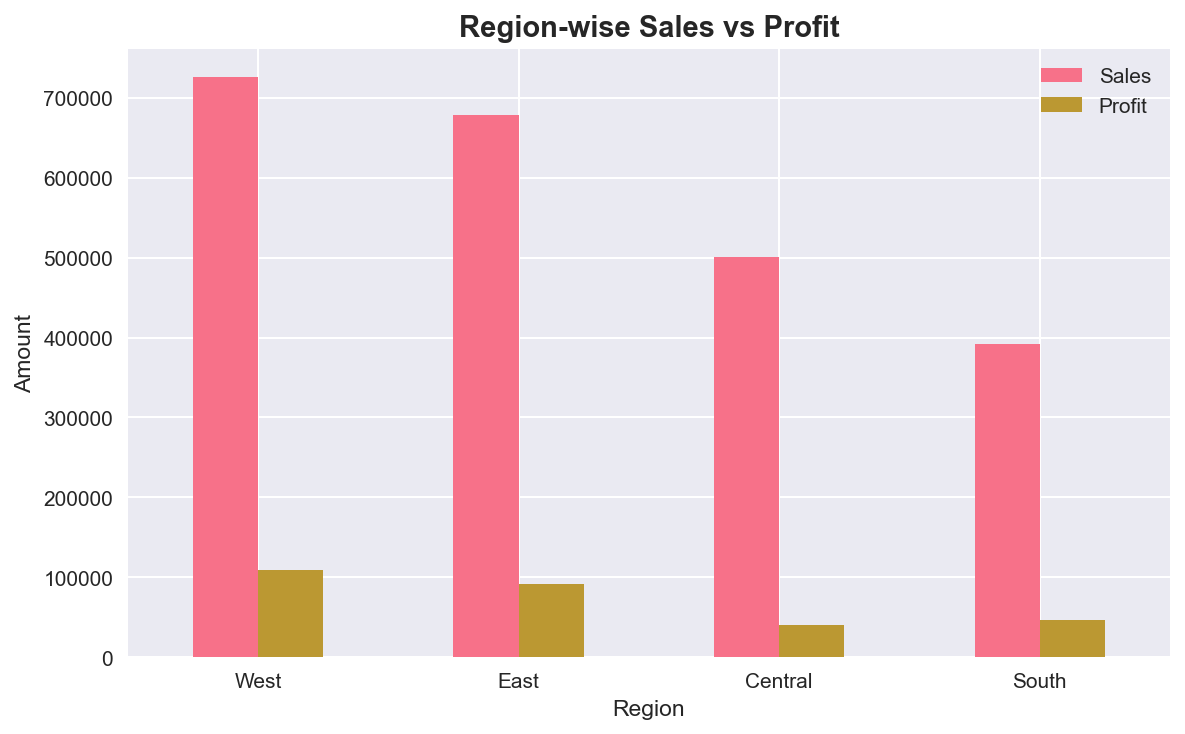

In [44]:
region_analysis[['Sales', 'Profit']].plot(kind='bar', figsize=(8,5))
plt.title('Region-wise Sales vs Profit')
plt.xlabel('Region')
plt.ylabel('Amount')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [29]:
region_margin = df.groupby('Region')['Profit_Margin'].mean().sort_values(ascending=False)
print(region_margin)

Region
West       21.948662
East       16.722696
South      16.351903
Central   -10.407294
Name: Profit_Margin, dtype: float64


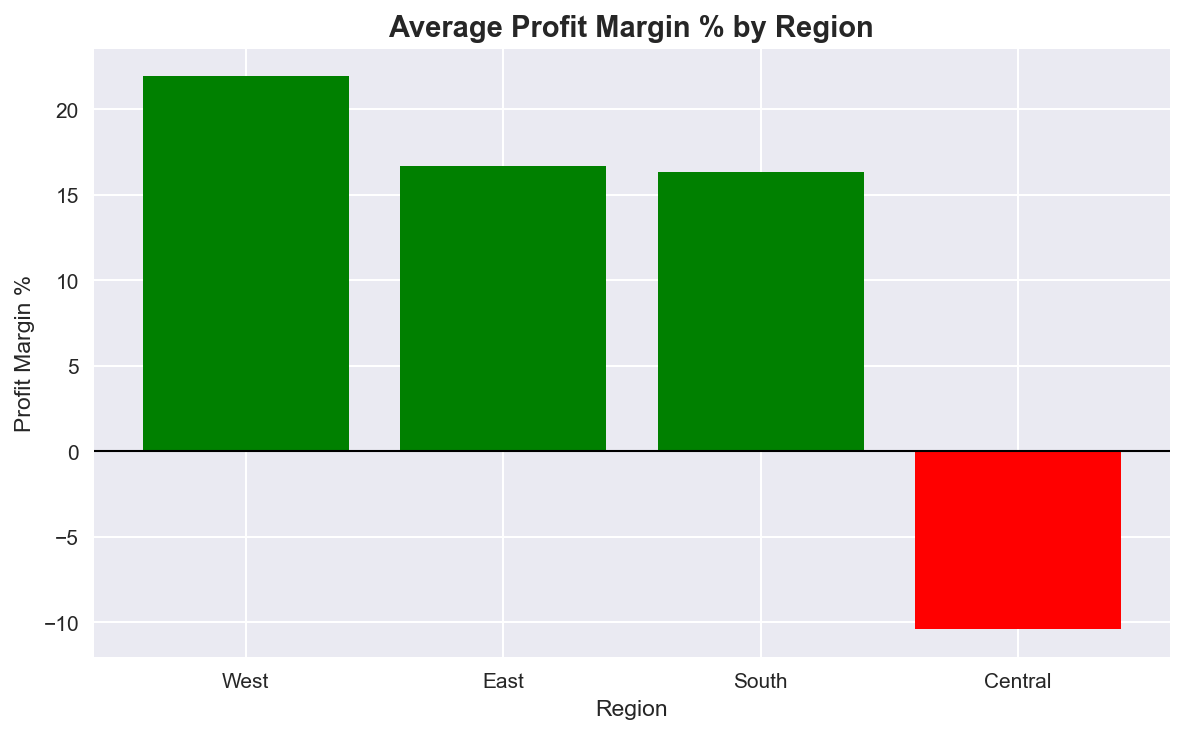

In [30]:
# Profit Margin by Region - Bar Chart
plt.figure(figsize=(8,5))
colors = ['green' if x > 0 else 'red' for x in region_margin.values]
plt.bar(region_margin.index, region_margin.values, color=colors)
plt.title('Average Profit Margin % by Region')
plt.xlabel('Region')
plt.ylabel('Profit Margin %')
plt.axhline(y=0, color='black', linewidth=1)
plt.tight_layout()
plt.show()

In [31]:
# Discount analysis by Region
region_discount = df.groupby('Region')['Discount'].mean().sort_values(ascending=False)
print(region_discount)

Region
Central    0.240353
South      0.147253
East       0.145365
West       0.109335
Name: Discount, dtype: float64


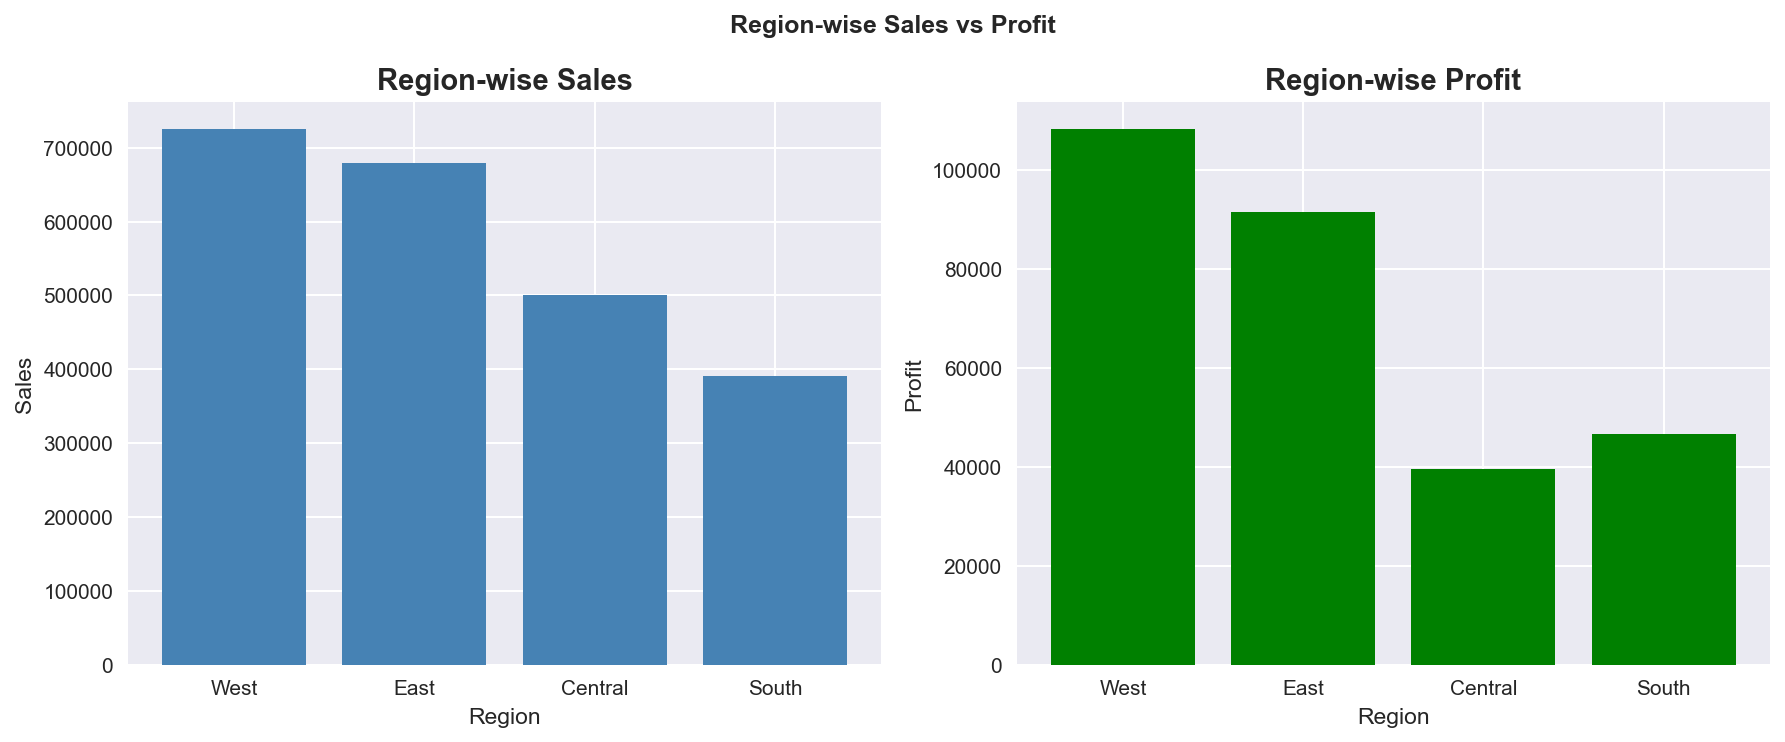

In [45]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Sales
ax1.bar(region_analysis.index, region_analysis['Sales'], color='steelblue')
ax1.set_title('Region-wise Sales')
ax1.set_xlabel('Region')
ax1.set_ylabel('Sales')

# Profit
colors = ['green' if x > 0 else 'red' for x in region_analysis['Profit'].values]
ax2.bar(region_analysis.index, region_analysis['Profit'], color=colors)
ax2.set_title('Region-wise Profit')
ax2.set_xlabel('Region')
ax2.set_ylabel('Profit')

plt.suptitle('Region-wise Sales vs Profit', fontweight='bold')
plt.tight_layout()
plt.show()

## 4. Sub-Category Deep Dive
Drilling down to sub-category level to identify specific product groups causing losses, and spotting hidden timebombs that appear profitable on the surface.

In [33]:
# Category-wise Profit in each Region
region_cat = df.groupby(['Region', 'Category'])['Profit'].sum().unstack()
print(region_cat)

Category   Furniture  Office Supplies  Technology
Region                                           
Central   -2871.0494        8879.9799  33697.4320
East       3046.1658       41014.5791  47462.0351
South      6771.2061       19986.3928  19991.8314
West      11504.9503       52609.8490  44303.6496


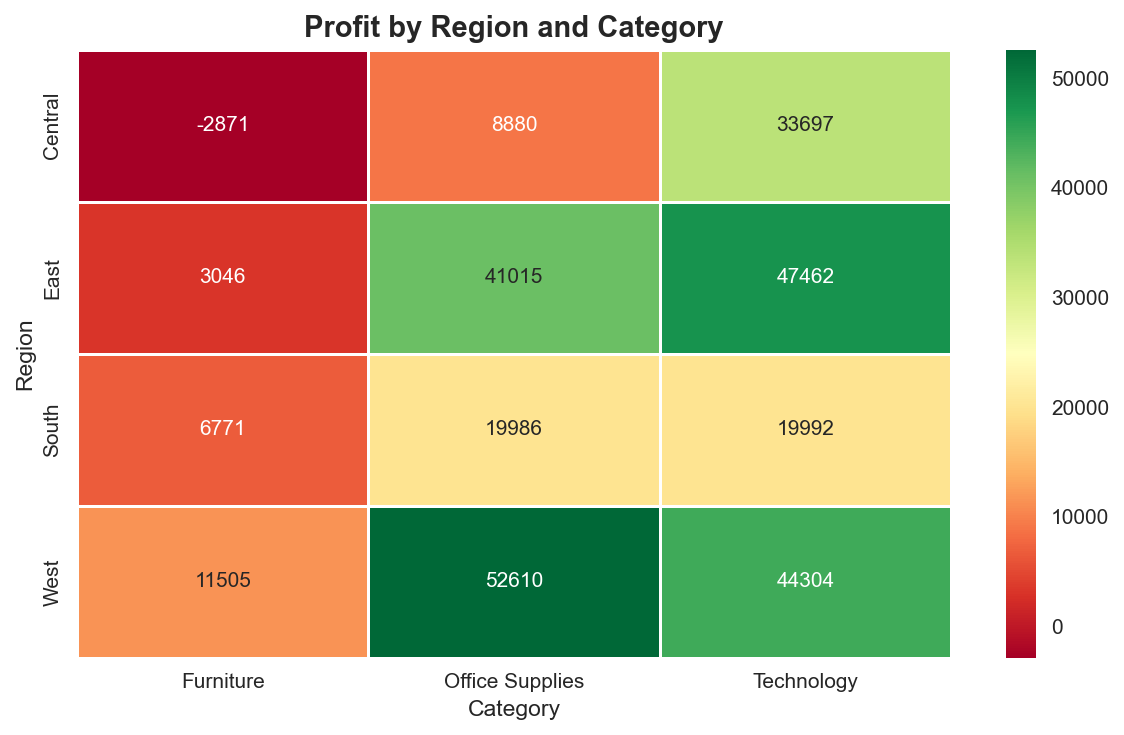

In [34]:
plt.figure(figsize=(8,5))
sns.heatmap(region_cat, annot=True, fmt='.0f', cmap='RdYlGn', linewidths=0.5)
plt.title('Profit by Region and Category')
plt.tight_layout()
plt.show()

In [35]:
# Discount bands banao
df['Discount_Band'] = pd.cut(df['Discount'], 
                              bins=[0, 0.1, 0.2, 0.3, 0.4, 0.5, 1.0],
                              labels=['0-10%', '10-20%', '20-30%', 
                                      '30-40%', '40-50%', '50%+'],
                              include_lowest=True)

# df.groupby('Discount_Band')['Profit'].mean()
df.groupby('Discount_Band', observed=True)['Profit'].mean()

Discount_Band
0-10%      67.460503
10-20%     24.738824
20-30%    -45.679636
30-40%   -109.219691
40-50%   -298.695314
50%+      -89.438144
Name: Profit, dtype: float64

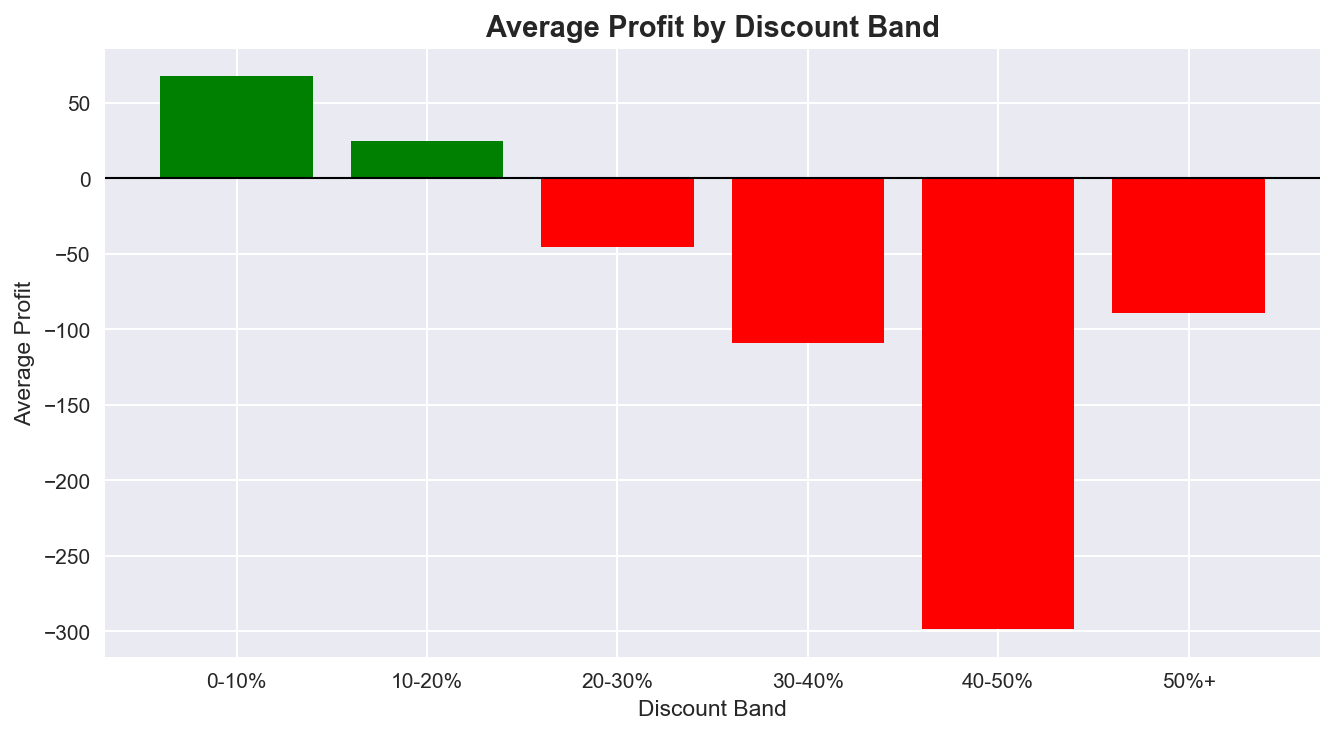

In [36]:
# discount_profit = df.groupby('Discount_Band')['Profit'].mean()
discount_profit = df.groupby('Discount_Band', observed=True)['Profit'].mean()

plt.figure(figsize=(9,5))
colors = ['green' if x > 0 else 'red' for x in discount_profit.values]
plt.bar(discount_profit.index, discount_profit.values, color=colors)
plt.axhline(y=0, color='black', linewidth=1)
plt.title('Average Profit by Discount Band')
plt.xlabel('Discount Band')
plt.ylabel('Average Profit')
plt.tight_layout()
plt.show()

In [37]:
cat_discount_profit = df.groupby(['Category', 'Discount_Band'], observed=True)['Profit'].mean().unstack()
print(cat_discount_profit)

Discount_Band         0-10%     10-20%     20-30%      30-40%      40-50%  \
Category                                                                    
Furniture         71.539571  11.521650 -48.177103 -182.142495 -236.374002   
Office Supplies   41.841713  17.282486        NaN         NaN         NaN   
Technology       159.497610  54.735560  65.207900  -52.440104 -636.269092   

Discount_Band          50%+  
Category                     
Furniture        -64.311076  
Office Supplies  -69.323732  
Technology      -851.274743  


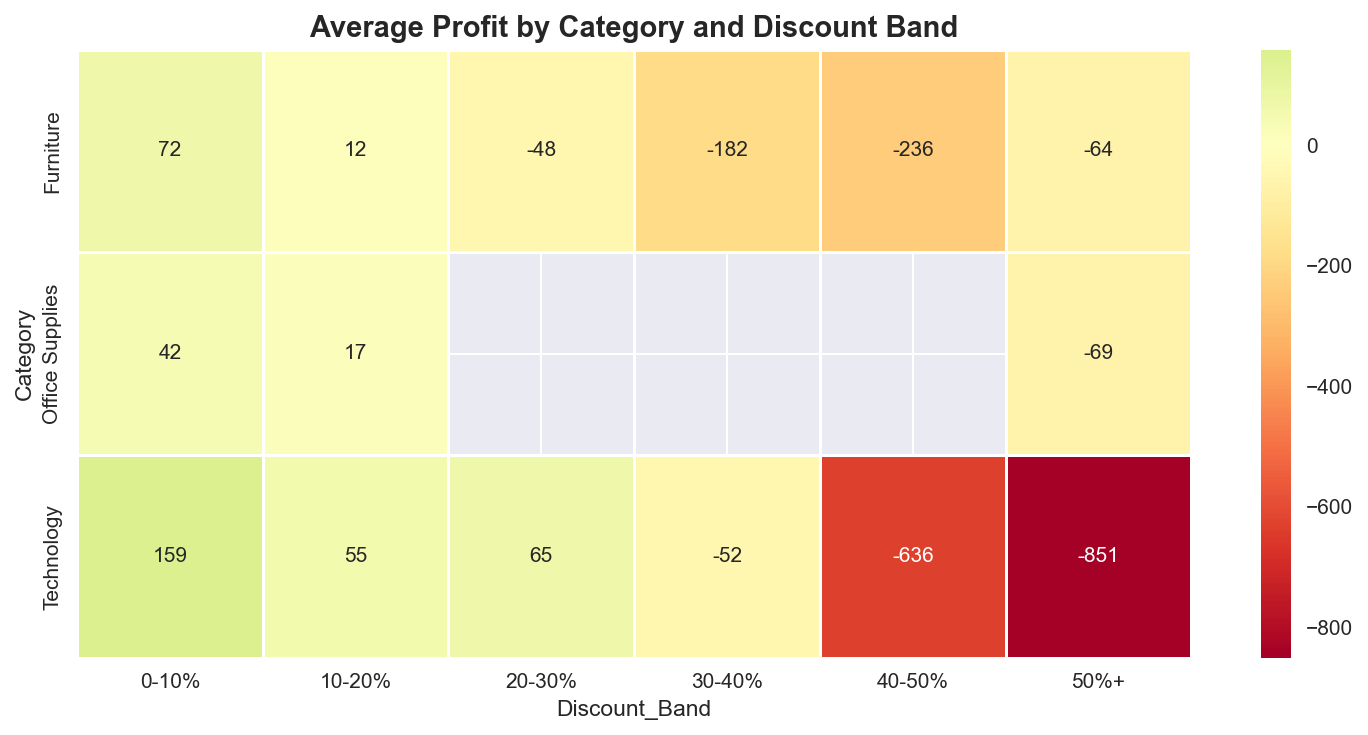

In [38]:
plt.figure(figsize=(10,5))
sns.heatmap(cat_discount_profit, annot=True, fmt='.0f', 
            cmap='RdYlGn', linewidths=0.5, center=0)
plt.title('Average Profit by Category and Discount Band')
plt.tight_layout()
plt.show()

In [39]:
# Top 10 loss making Sub-Categories
subcat_analysis = df.groupby('Sub-Category').agg({
    'Sales': 'sum',
    'Profit': 'sum',
    'Discount': 'mean'
}).sort_values(by='Profit')

print(subcat_analysis.head(10))

                    Sales      Profit  Discount
Sub-Category                                   
Tables        206965.5320 -17725.4811  0.261285
Bookcases     114879.9963  -3472.5560  0.211140
Supplies       46673.5380  -1189.0995  0.076842
Fasteners       3024.2800    949.5182  0.082028
Machines      189238.6310   3384.7569  0.306087
Labels         12486.3120   5546.2540  0.068681
Art            27118.7920   6527.7870  0.074874
Envelopes      16476.4020   6964.1767  0.080315
Furnishings    91705.1640  13059.1436  0.138349
Appliances    107532.1610  18138.0054  0.166524


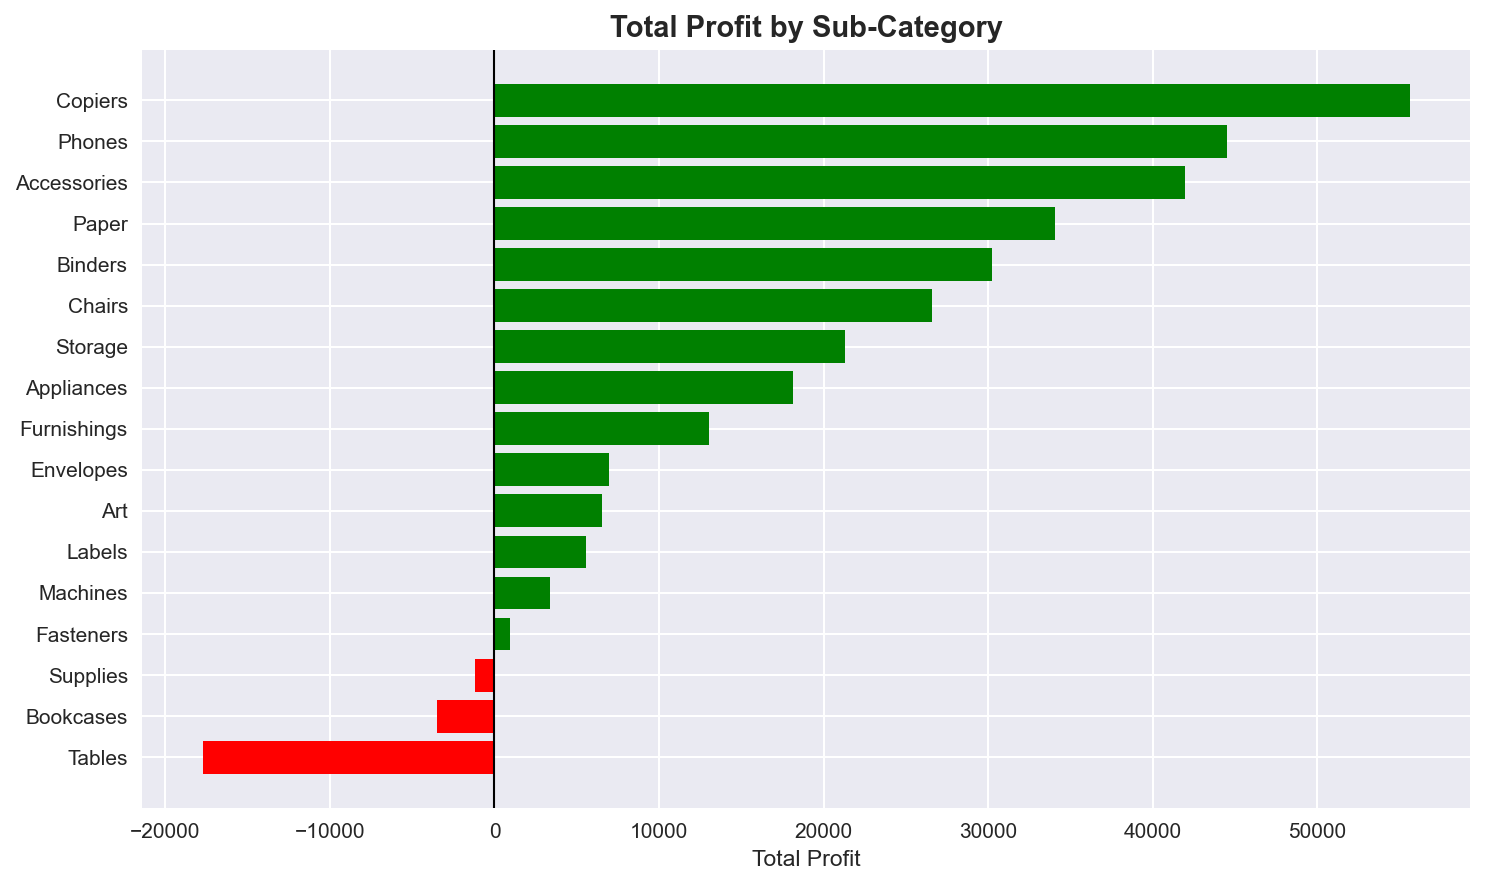

In [40]:
plt.figure(figsize=(10,6))
colors = ['red' if x < 0 else 'green' for x in subcat_analysis['Profit'].values]
plt.barh(subcat_analysis.index, subcat_analysis['Profit'], color=colors)
plt.axvline(x=0, color='black', linewidth=1)
plt.title('Total Profit by Sub-Category')
plt.xlabel('Total Profit')
plt.tight_layout()
plt.show()

In [41]:
# Machines deep dive - high discount, thin profit
machines = df[df['Sub-Category'] == 'Machines'].groupby('Region').agg({
    'Sales': 'sum',
    'Profit': 'sum',
    'Discount': 'mean'
}).sort_values(by='Profit')

print(machines)

             Sales     Profit  Discount
Region                                 
Central  26797.384 -1486.0666  0.328571
South    53890.960 -1438.8930  0.333333
West     42444.122  -618.9264  0.302564
East     66106.165  6928.6429  0.283784


## 5. Key Findings & Business Recommendations

In [42]:
# ============================================
# SUPERSTORE EDA - KEY FINDINGS SUMMARY
# ============================================

print("""
📦 SUPERSTORE - WHAT THE DATA IS TELLING US
============================================

So after digging through 9,994 transactions, here's the real story:

🔴 THE MAIN VILLAIN: DISCOUNTS
   Anything above 20% discount is bleeding money.
   At 40-50% discount, we're losing ₹298 on average per transaction.
   Someone in the discount approval chain needs a reality check.

📍 REGION ALERT: CENTRAL IS BROKEN
   Central region is doing 501k in sales and still losing money.
   Profit margin: -10.4%. Why? Average discount of 24%.
   Every other region stays under 15% — Central blows past it.
   West on the other hand? 10.9% discount, 21.9% margin. 
   That's what a healthy region looks like.

🪑 FURNITURE: THE PROBLEM CHILD
   Tables alone lost ₹17,725. Bookcases another ₹3,472.
   Both being heavily discounted — 26% and 21% respectively.
   Ironically, Chairs and Furnishings in the same category are profitable.
   The product isn't the problem. The discount strategy is.

⚠️  MACHINES: THE HIDDEN TIMEBOMB
   Overall profit looks okay at ₹3,384.
   But zoom in — Central, South, West all losing money on Machines.
   Only East is profitable, and it's carrying the whole category.
   One bad quarter in East and this category collapses.

✅ WHAT'S WORKING
   Technology + low discounts = great margins.
   West region = proof that discipline in discounting works.
   Office Supplies = never discounted beyond 20%, stayed safe.

💡 THE ONE FIX THAT SOLVES MOST OF THIS:
   Cap discounts at 20% company-wide.
   That single policy change would likely turn Central profitable
   and save Tables, Bookcases, and Machines from further losses.
""")


📦 SUPERSTORE - WHAT THE DATA IS TELLING US

So after digging through 9,994 transactions, here's the real story:

🔴 THE MAIN VILLAIN: DISCOUNTS
   Anything above 20% discount is bleeding money.
   At 40-50% discount, we're losing ₹298 on average per transaction.
   Someone in the discount approval chain needs a reality check.

📍 REGION ALERT: CENTRAL IS BROKEN
   Central region is doing 501k in sales and still losing money.
   Profit margin: -10.4%. Why? Average discount of 24%.
   Every other region stays under 15% — Central blows past it.
   West on the other hand? 10.9% discount, 21.9% margin. 
   That's what a healthy region looks like.

🪑 FURNITURE: THE PROBLEM CHILD
   Tables alone lost ₹17,725. Bookcases another ₹3,472.
   Both being heavily discounted — 26% and 21% respectively.
   Ironically, Chairs and Furnishings in the same category are profitable.
   The product isn't the problem. The discount strategy is.

⚠️  MACHINES: THE HIDDEN TIMEBOMB
   Overall profit looks okay at 